<a href="https://colab.research.google.com/github/arelkeselbri/gsi073/blob/main/aula5_visualizacao_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 5: Embeddings com modelo *encoder-only* e visualização

Nesta prática você vai usar embeddings e verificar visualmente a intuição de que conceitos semânticos estão espacialmente próximos nos embeddings.

O roteiro é:

1. **Carregar um modelo *encoder-only* para embeddings**.
2. **Gerar embeddings por sentença** para uma coleção de documentos.
3. **Reduzir a dimensionalidade** e **plotar em 2D** para inspecionar agrupamentos.

---


## 0) Setup do ambiente

Vamos instalar dependências e importar bibliotecas.


In [1]:
# Se necessário, instale dependências (descomente e rode)
# !pip -q install -U sentence-transformers scikit-learn matplotlib pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, FastICA

# Opcional: para separar sentenças de forma simples (sem libs pesadas)
import re


## 1) Mini-dataset
Vamos criar uma coleção pequena de documentos, com **rótulos de tópico** (categorias).
Você pode substituir por textos reais (artigos, notícias, parágrafos de PDFs, etc.).


In [4]:
docs = [

  {
    "id": "s1",
    "label": "saude",
    "text": "O prontuário de emergência deve detalhar meticulosamente os sinais vitais imediatos e o histórico de alergias para evitar interações negativas. A análise de biópsia fornece a base diagnóstica definitiva na oncologia moderna para planos terapêuticos personalizados. O monitoramento contínuo da glicemia em pacientes diabéticos é fundamental para prevenir complicações agudas como a cetoacidose."
  },
  {
    "id": "s2",
    "label": "saude",
    "text": "A vacinação em massa atua na criação de uma barreira epidemiológica que reduz a circulação de patógenos virais em comunidades. Protocolos de higiene hospitalar rigorosos são a primeira linha de defesa contra o surgimento de bactérias multirresistentes em UTIs. A reabilitação fisioterapêutica foca na restauração da amplitude de movimento e no fortalecimento muscular pós-operatório."
  },
  {
    "id": "t1",
    "label": "tecnologia",
    "text": "A arquitetura de microsserviços permite que grandes plataformas escalem componentes de forma independente utilizando containers orquestrados. O desenvolvimento de modelos de linguagem exige vastos conjuntos de dados para o pré-treinamento de parâmetros em larga escala. A implementação de criptografia de ponta a ponta é essencial para garantir a integridade das comunicações em redes públicas."
  },
  {
    "id": "t2",
    "label": "tecnologia",
    "text": "Sistemas de gerenciamento de banco de dados utilizam transações ACID para assegurar que as operações sejam executadas sem corrupção. A computação de borda reduz a latência ao processar informações próximas à fonte geradora em dispositivos de IoT. O deploy contínuo em nuvem híbrida facilita a entrega rápida de novas funcionalidades através de pipelines automatizados."
  },
  {
    "id": "n1",
    "label": "natureza",
    "text": "O ecossistema da Mata Atlântica possui altas taxas de endemismo abrigando espécies que dependem da umidade da vegetação densa. A acidificação dos oceanos resultante da absorção de dióxido de carbono compromete a formação de recifes de coral. O ciclo hidrológico em bacias amazônicas é alimentado por rios voadores que transportam umidade para o continente."
  },
  {
    "id": "n2",
    "label": "natureza",
    "text": "A sucessão ecológica em áreas degradadas começa com espécies pioneiras que alteram a química do solo para o crescimento futuro. Fenômenos meteorológicos extremos tornam-se mais frequentes devido ao aumento da temperatura superficial das águas oceânicas. A fotossíntese é o processo fundamental de conversão de energia solar em biomassa sustentando as cadeias alimentares."
  },
  {
    "id": "s3",
    "label": "saude",
    "text": "A terapia gênica representa uma fronteira promissora para o tratamento de desordens hereditárias através da edição de sequências de DNA específicas. O manejo da dor crônica exige uma abordagem multidisciplinar envolvendo farmacologia e intervenções psicossociais coordenadas. A triagem neonatal permite a detecção precoce de erros inatos do metabolismo garantindo intervenções dietéticas imediatas."
  },
  {
    "id": "t3",
    "label": "tecnologia",
    "text": "A otimização de hiperparâmetros em redes neurais profundas utiliza técnicas de busca em grade ou otimização bayesiana para melhorar a acurácia. Protocolos de consenso em redes descentralizadas garantem a imutabilidade dos registros sem a necessidade de uma autoridade central. A realidade aumentada integra elementos digitais ao campo visual humano em tempo real com baixa latência de renderização."
  },
  {
    "id": "n3",
    "label": "natureza",
    "text": "A deriva continental explica a distribuição atual de fósseis idênticos em continentes separados por vastos oceanos. Zonas de subducção em placas tectônicas são responsáveis pela atividade sísmica intensa e pela formação de arcos vulcânicos. A polinização biótica realizada por insetos e aves é crucial para a reprodução de grande parte das angiospermas terrestres."
  },
  {
    "id": "s4",
    "label": "saude",
    "text": "A farmacocinética de novos agentes biológicos exige estudos rigorosos sobre o tempo de meia-vida plasmática e as vias de excreção renal para evitar toxicidade acumulada em pacientes com insuficiência moderada. O protocolo de Manchester é essencial para a gestão do fluxo assistencial em prontos-socorros, priorizando casos de infarto agudo do miocárdio sobre patologias de baixa complexidade sistêmica. A ventilação mecânica invasiva deve ser ajustada com volumes correntes baixos para prevenir a lesão pulmonar induzida pelo ventilador em quadros de síndrome do desconforto respiratório agudo."
  },
  {
    "id": "s5",
    "label": "saude",
    "text": "O rastreamento mamográfico periódico em mulheres acima dos cinquenta anos reduz significativamente a mortalidade específica por câncer de mama através da detecção de lesões não palpáveis em estágios iniciais. A resistência insulínica periférica é um marco fisiopatológico da síndrome metabólica que predispõe o indivíduo ao desenvolvimento precoce de aterosclerose coronariana e eventos vasculares cerebrais. A bioética clínica orienta que o termo de consentimento livre e esclarecido deve garantir que o paciente compreenda todos os riscos inerentes a procedimentos experimentais ou cirurgias de alto risco."
  },
  {
    "id": "s6",
    "label": "saude",
    "text": "A microbiota intestinal desempenha um papel crucial na modulação do sistema imunológico e na síntese de vitaminas essenciais, sendo influenciada diretamente pelo consumo crônico de alimentos ultraprocessados. Exames de ecocardiografia com Doppler colorido permitem avaliar o fluxo transvalvar e a fração de ejeção do ventrículo esquerdo, sendo fundamentais no manejo da insuficiência cardíaca congestiva. O uso de antibióticos de amplo espectro deve ser reservado para infecções graves com o intuito de minimizar a pressão seletiva sobre patógenos hospitalares e preservar a eficácia dos tratamentos disponíveis."
  },
  {
    "id": "t4",
    "label": "tecnologia",
    "text": "O treinamento de redes neurais convolucionais para visão computacional depende fortemente da normalização dos dados de entrada e da escolha adequada de funções de ativação como a ReLU para evitar o desvanecimento do gradiente. A infraestrutura como código permite que equipes de operações provisionem servidores e redes de forma programática, garantindo a repetibilidade do ambiente e a redução de erros humanos em larga escala. O protocolo gRPC utiliza buffers de protocolo para serialização de dados, oferecendo uma alternativa mais eficiente e performática ao tradicional REST sobre JSON em comunicações entre serviços."
  },
  {
    "id": "t5",
    "label": "tecnologia",
    "text": "Sistemas de arquivos distribuídos como o HDFS são projetados para armazenar grandes volumes de dados em hardware comum, provendo tolerância a falhas através da replicação automática de blocos em diferentes nós do cluster. A análise de sentimentos em processamento de linguagem natural utiliza arquiteturas de transformadores para capturar o contexto semântico de frases longas e identificar nuances de sarcasmo ou ironia em textos não estruturados. O desenvolvimento front-end moderno utiliza o conceito de Virtual DOM para otimizar a renderização de componentes, atualizando apenas as partes da interface que sofreram mudanças de estado efetivas."
  },
  {
    "id": "t6",
    "label": "tecnologia",
    "text": "A tecnologia de Ray Tracing em placas de vídeo modernas simula o comportamento físico da luz para gerar reflexos e sombras realistas em ambientes virtuais de alta fidelidade visual. Ambientes de execução serverless permitem que desenvolvedores foquem exclusivamente no código da função, enquanto o provedor de nuvem gerencia automaticamente a alocação de recursos e a escalabilidade baseada na demanda. O padrão OAuth 2.0 define fluxos específicos para que aplicações de terceiros obtenham acesso limitado a recursos de um usuário sem a necessidade de compartilhar credenciais de login confidenciais."
  },
  {
    "id": "n4",
    "label": "natureza",
    "text": "A estratificação térmica em lagos de grande profundidade cria camadas de água com densidades distintas, impedindo a mistura de nutrientes e oxigênio entre a superfície e o hipolímnio durante o verão. O processo de seleção natural proposto por Darwin atua sobre a variabilidade genética das populações, favorecendo fenótipos que conferem maior sucesso reprodutivo em ambientes específicos sob pressão seletiva constante. Os recifes de coral abrigam uma densidade populacional de organismos marinhos sem paralelo, funcionando como barreiras naturais contra a erosão costeira provocada pela energia das ondas oceânicas."
  },
  {
    "id": "n5",
    "label": "natureza",
    "text": "A sucessão primária ocorre em superfícies recém-formadas, como fluxos de lava resfriados, onde líquens e briófitas iniciam a formação do solo através da decomposição química da rocha matriz. O efeito albedo descreve a fração da rad"
  }, 
  {
    "id": "n6",
    "label": "natureza",
    "text": "A biomimética busca na natureza soluções de design e engenharia, como a estrutura hidrodinâmica da pele de tubarões para criar revestimentos que reduzem o arrasto em embarcações e aeronaves. O permafrost nas regiões árticas armazena vastas quantidades de metano orgânico, cujo degelo acelerado pode desencadear um ciclo de retroalimentação positiva no aquecimento global. A fragmentação de habitats devido à expansão urbana cria ilhas de vegetação que isolam populações animais, reduzindo a variabilidade genética e aumentando o risco de extinção local de grandes carnívoros."
  },
  {
    "id": "s7",
    "label": "saude",
    "text": "O monitoramento da pressão intracraniana é um componente crítico no manejo de pacientes com traumatismo cranioencefálico grave para prevenir a herniação cerebral decorrente do edema citotóxico. A farmacovigilância desempenha um papel vital na detecção precoce de reações adversas raras que não foram identificadas durante as fases iniciais dos ensaios clínicos controlados. O uso de estatinas na prevenção primária de doenças cardiovasculares visa a estabilização de placas ateroscleróticas e a redução dos níveis de lipoproteína de baixa densidade no soro sanguíneo."
  },
  {
    "id": "s8",
    "label": "saude",
    "text": "A terapia de substituição renal, como a hemodiálise contínua, é frequentemente necessária em quadros de injúria renal aguda séptica para manter o equilíbrio hidroeletrolítico e a homeostase ácido-base. O rastreamento do câncer colorretal através da colonoscopia permite a identificação e exérese de pólipos adenomatosos antes que estes sofram transformação maligna para adenocarcinoma. A medicina de precisão utiliza o sequenciamento de nova geração para identificar variantes genéticas somáticas que guiam a escolha de inibidores de tirosina quinase em protocolos oncológicos."
  },
  {
    "id": "s9",
    "label": "saude",
    "text": "A depressão pós-parto requer uma abordagem diagnóstica sensível que diferencie o 'baby blues' transitório de quadros clínicos severos que podem comprometer o vínculo afetivo entre a puérpera e o neonato. O protocolo de reanimação neonatal em sala de parto enfatiza a ventilação com pressão positiva como a medida mais eficaz para reverter a apneia ou bradicardia em recém-nascidos de termo. A reabilitação neuropsicológica pós-AVC foca na plasticidade cerebral para recuperar funções cognitivas superiores, como a memória de trabalho e as funções executivas prejudicadas pela isquemia."
  },
  {
    "id": "t7",
    "label": "tecnologia",
    "text": "O balanceamento de carga em arquiteturas de alta disponibilidade distribui o tráfego de entrada entre múltiplos servidores para evitar gargalos de processamento e garantir tempos de resposta consistentes. A técnica de Sharding em bancos de dados NoSQL particiona horizontalmente os dados em diferentes clusters para permitir que o sistema suporte volumes massivos de operações de escrita simultâneas. O desenvolvimento de contratos inteligentes em redes blockchain utiliza linguagens de programação Turing-completas para automatizar a execução de acordos financeiros sem a necessidade de intermediários fiduciários."
  },
  {
    "id": "t8",
    "label": "tecnologia",
    "text": "A virtualização de funções de rede permite que serviços de firewall e roteamento sejam executados como instâncias de software em hardware genérico, reduzindo custos operacionais e aumentando a agilidade da infraestrutura. O processamento de fluxos de dados em tempo real através de ferramentas como Apache Kafka permite a ingestão e análise de eventos complexos com latência na casa dos milissegundos. A engenharia de prompts para modelos de linguagem avançados envolve a estruturação cuidadosa de instruções contextuais para minimizar a ocorrência de alucinações e maximizar a precisão factual."
  },
  {
    "id": "t9",
    "label": "tecnologia",
    "text": "A implementação de redes neurais recorrentes com células de memória de curto e longo prazo (LSTM) é ideal para o tratamento de séries temporais onde as dependências históricas influenciam as previsões futuras. O paradigma de programação funcional enfatiza a imutabilidade dos dados e a ausência de efeitos colaterais, facilitando o teste e a manutenção de sistemas complexos e concorrentes. A autenticação multifator baseada em padrões FIDO2 utiliza criptografia de chave pública para oferecer uma proteção robusta contra ataques de phishing e interceptação de sessões de usuário."
  },
  {
    "id": "n7",
    "label": "natureza",
    "text": "O fenômeno do ressurgimento costeiro traz águas profundas e ricas em nutrientes para a superfície, impulsionando a produtividade primária do fitoplâncton e sustentando vastos estoques pesqueiros regionais. A especiação alopátrica ocorre quando uma barreira geográfica física isola populações de uma mesma espécie, levando à divergência genética acumulada ao longo de milhares de anos de evolução independente. O ciclo do carbono nas turfeiras desempenha um papel fundamental no clima global, uma vez que esses ecossistemas retêm quantidades massivas de matéria orgânica sob condições anaeróbicas."
  },
  {
    "id": "n8",
    "label": "natureza",
    "text": "A bioacumulação de metais pesados em cadeias alimentares aquáticas resulta em concentrações tóxicas nos predadores de topo, representando um risco significativo para a saúde ambiental e humana. O vulcanismo de ponto quente, como o observado nas ilhas do Havaí, resulta da ascensão de plumas mantélicas que perfuram a placa tectônica em movimento, criando cadeias de montanhas submarinas. A dispersão de sementes por grandes mamíferos frugívoros é um serviço ecossistêmico essencial para a manutenção da diversidade arbórea em florestas tropicais úmidas altamente fragmentadas."
  },
  {
    "id": "n9",
    "label": "natureza",
    "text": "A resiliência de recifes de coral frente ao branqueamento depende da diversidade de clados de zooxantelas simbiontes que possuem diferentes limiares de tolerância ao estresse térmico oceânico. O regime de distúrbios naturais, como incêndios florestais de baixa intensidade, é necessário para a germinação de certas espécies cujas sementes possuem dormência quebrada apenas pelo calor extremo. A formação de zonas mortas ou hipóxicas em estuários é frequentemente causada pela eutrofização antrópica decorrente do escoamento excessivo de fertilizantes nitrogenados de áreas agrícolas próximas."
  },
  {
    "id": "s10",
    "label": "saude",
    "text": "A fisiopatologia da pré-eclâmpsia envolve uma invasão trofoblástica inadequada das artérias espiraladas, resultando em hipóxia placentária e na liberação de fatores antiangiogênicos na circulação materna. O manejo da cetoacidose diabética requer a reposição volêmica vigorosa com solução salina isotônica associada à infusão contínua de insulina regular para normalizar o hiato aniônico e cessar a cetogênese. A polifarmácia em pacientes geriátricos aumenta exponencialmente o risco de quedas e episódios de confusão mental devido a alterações na farmacodinâmica e na depuração renal de metabólitos ativos."
  },
  {
    "id": "s11",
    "label": "saude",
    "text": "O rastreamento de aneurismas da aorta abdominal por ultrassonografia é indicado para homens tabagistas acima de sessenta e cinco anos visando a intervenção cirúrgica eletiva antes da ruptura catastrófica. A ventilação não invasiva com pressão positiva binível é a modalidade de escolha no tratamento do edema agudo de pulmão cardiogênico para reduzir a pré-carga e melhorar a complacência ventricular. O diagnóstico diferencial entre a demência de Alzheimer e a demência vascular baseia-se na progressão temporal dos déficits cognitivos e na presença de lesões isquêmicas em exames de neuroimagem estrutural."
  },
  {
    "id": "s12",
    "label": "saude",
    "text": "A suplementação de ácido fólico no período periconcepcional é uma medida de saúde pública fundamental para reduzir a incidência de defeitos do fechamento do tubo neural, como a mielomeningocele. O tratamento da sepse grave nas primeiras horas exige a coleta de hemoculturas e o início imediato de antibioticoterapia empírica de amplo espectro direcionada aos prováveis focos infecciosos. A reabilitação cardíaca fase II utiliza o treinamento físico supervisionado para melhorar o limiar isquêmico e promover modificações favoráveis no perfil lipídico de pacientes pós-infarto."
  },
  {
    "id": "t10",
    "label": "tecnologia",
    "text": "A implementação de redes neurais generativas adversárias (GANs) utiliza um processo de treinamento competitivo onde um gerador cria dados sintéticos enquanto um discriminador tenta distinguir entre exemplos reais e artificiais. A governança de dados em grandes corporações exige políticas de linhagem de dados para rastrear a origem e as transformações sofridas pela informação ao longo de todo o ciclo de vida analítico. O desenvolvimento de sistemas operacionais modernos depende do gerenciamento eficiente de interrupções de hardware para garantir que o escalonador de processos mantenha a responsividade multitarefa."
  },
  {
    "id": "t11",
    "label": "tecnologia",
    "text": "A computação quântica utiliza o fenômeno da superposição para processar múltiplos estados simultaneamente, permitindo a resolução de problemas de fatoração de inteiros que seriam intratáveis para computadores clássicos. O protocolo TLS 1.3 removeu algoritmos de criptografia obsoletos e simplificou o aperto de mão inicial para reduzir a latência de conexão e aumentar a segurança contra ataques de downgrade. A virtualização de desktop permite que o poder de processamento seja centralizado em servidores de alto desempenho, enquanto o usuário final interage com a interface através de clientes magros ou navegadores web."
  },
  {
    "id": "t12",
    "label": "tecnologia",
    "text": "Sistemas de busca semântica utilizam modelos de linguagem baseados em transformadores para converter consultas em linguagem natural em vetores matemáticos que representam o significado profundo do conteúdo pesquisado. A arquitetura de rede definida por software (SDN) separa o plano de controle do plano de dados, permitindo que administradores programem o comportamento de roteamento de forma dinâmica e centralizada. O uso de técnicas de poda em modelos de Deep Learning remove conexões neurais redundantes ou de baixo peso para permitir que a inferência seja executada em dispositivos com recursos computacionais limitados."
  },
  {
    "id": "n10",
    "label": "natureza",
    "text": "O ciclo biogeoquímico do fósforo é único entre os principais nutrientes por não possuir uma fase gasosa significativa, dependendo quase exclusivamente da intemperização de rochas fosfáticas para entrar nas cadeias tróficas. A estratificação florestal em selvas tropicais cria nichos ecológicos distintos onde a intensidade luminosa e a umidade relativa variam drasticamente entre o solo e o topo das árvores mais altas. A migração vertical diária do zooplâncton marinho representa o maior movimento de biomassa do planeta, ocorrendo em resposta aos ciclos de luz solar para evitar predadores visuais durante o dia."
  },
  {
    "id": "n11",
    "label": "natureza",
    "text": "A erosão eólica em regiões áridas molda o relevo através de processos de deflação e abrasão, transportando partículas finas de poeira através de oceanos e fertilizando florestas distantes como a Amazônia. O mutualismo entre fungos micorrízicos e as raízes das plantas aumenta a eficiência na absorção de minerais escassos em troca de carboidratos produzidos pela fotossíntese vegetal. A homeostase térmica em animais endotérmicos é mantida através de mecanismos fisiológicos complexos como a vasodilatação periférica e a termogênese por calafrios em resposta a flutuações ambientais."
  },
  {
    "id": "n12",
    "label": "natureza",
    "text": "A sucessão ecológica secundária em campos abandonados ocorre de forma muito mais rápida que a primária, pois o solo já contém um banco de sementes e nutrientes essenciais para o restabelecimento da vegetação. O fenômeno do El Niño altera drasticamente os padrões de circulação atmosférica global, resultando em secas severas na Austrália e chuvas torrenciais na costa oeste da América do Sul. A diversidade genética dentro de uma população é a matéria-prima da evolução, permitindo que os indivíduos se adaptem a mudanças ambientais repentinas ou ao surgimento de novas doenças infecciosas."
  },
  {
    "id": "s13",
    "label": "saude",
    "text": "O manejo farmacológico da dor neuropática crônica frequentemente envolve a modulação de canais de cálcio voltagem-dependentes através de ligandos alfa-2-delta para reduzir a hiperexcitabilidade neuronal no corno dorsal da medula espinhal. A triagem para retinopatia diabética por meio de fundoscopia sob midríase é imperativa para prevenir a perda visual irreversível decorrente de neovascularização e edema macular. O transplante de células-tronco hematopoiéticas exige um condicionamento mieloablativo rigoroso para erradicar clones celulares malignos e permitir o 'pegamento' do enxerto em pacientes com leucemia mieloide aguda."
  },
  {
    "id": "s14",
    "label": "saude",
    "text": "A fisiologia do sistema renina-angiotensina-aldosterona desempenha um papel central na regulação da pressão arterial a longo prazo e no equilíbrio hidroeletrolítico através da reabsorção distal de sódio e água. Protocolos de ressuscitação volêmica na sepse devem ser guiados por metas hemodinâmicas dinâmicas para evitar a sobrecarga hídrica e a consequente disfunção orgânica associada ao edema intersticial difuso. A vigilância epidemiológica de doenças de notificação compulsória permite a implementação imediata de medidas de bloqueio vacinal e controle de vetores para mitigar surtos em áreas urbanas densamente povoadas."
  },
  {
    "id": "s15",
    "label": "saude",
    "text": "A farmacodinâmica dos inibidores da bomba de prótons baseia-se na inativação irreversível da enzima H+/K+ ATPase nas células parietais gástricas, resultando em uma supressão profunda e prolongada da secreção ácida. O diagnóstico de embolia pulmonar requer a integração de scores de probabilidade clínica com o resultado de angiotomografia computadorizada de tórax para identificar falhas de enchimento nas artérias pulmonares. A reabilitação após lesão medular foca na neuroplasticidade e no uso de tecnologias assistivas para maximizar a independência funcional e prevenir complicações secundárias como úlceras por pressão e atrofia muscular."
  },
  {
    "id": "t13",
    "label": "tecnologia",
    "text": "O desenvolvimento de compiladores modernos envolve técnicas avançadas de análise de fluxo de dados e otimização de código para reduzir o tempo de execução e o consumo de energia em arquiteturas multicore. A integração de sistemas via barramentos de serviços corporativos (ESB) facilita a interoperabilidade entre aplicações legadas e microserviços contemporâneos através de transformações de protocolo e roteamento inteligente. A segurança em nível de hardware utilizando enclaves seguros, como o Intel SGX, permite o processamento de dados confidenciais em ambientes de nuvem potencialmente não confiáveis."
  },
  {
    "id": "t14",
    "label": "tecnologia",
    "text": "A virtualização de rede baseada em VXLAN encapsula quadros Ethernet de camada 2 em pacotes UDP de camada 3, permitindo a criação de redes lógicas extensas sobre infraestruturas físicas de roteamento IP. O treinamento de modelos de difusão para geração de imagens utiliza um processo iterativo de remoção de ruído gaussiano para reconstruir amostras de alta fidelidade a partir de estados puramente aleatórios. A implementação de arquiteturas orientadas a eventos utiliza corretores de mensagens para desacoplar produtores e consumidores de dados, garantindo alta escalabilidade e resiliência em sistemas distribuídos complexos."
  },
  {
    "id": "t15",
    "label": "tecnologia",
    "text": "O uso de técnicas de processamento de linguagem natural para análise de código-fonte permite a detecção automática de vulnerabilidades de segurança e padrões de design ineficientes durante o processo de revisão de código. A computação confidencial utiliza ambientes de execução confiáveis (TEE) para garantir que os dados permaneçam criptografados mesmo durante o processamento na memória RAM. Protocolos de roteamento dinâmico como o BGP são fundamentais para a estabilidade da internet global ao gerenciar a troca de informações de acessibilidade entre diferentes sistemas autônomos."
  },
  {
    "id": "n13",
    "label": "natureza",
    "text": "A geomorfologia de sistemas cársticos é caracterizada pela dissolução química de rochas carbonáticas, resultando na formação de dolinas, cavernas e complexas redes de drenagem subterrânea. O ciclo biogeoquímico do enxofre envolve processos de oxidação e redução mediados por microrganismos que transformam compostos inorgânicos em formas assimiláveis pela biota terrestre e marinha. A radiação adaptativa observada em arquipélagos isolados ilustra como uma única linhagem ancestral pode diversificar-se rapidamente em múltiplas espécies ocupando nichos ecológicos distintos."
  },
  {
    "id": "n14",
    "label": "natureza",
    "text": "A regulação do ciclo do nitrogênio nos oceanos depende do equilíbrio entre a fixação biológica realizada por cianobactérias e os processos de desnitrificação e anammox que devolvem o gás nitrogênio à atmosfera. O intemperismo físico e químico das rochas é o processo primário de formação do solo, liberando minerais essenciais que sustentam a produtividade dos ecossistemas terrestres. A termorregulação em répteis depende de comportamentos ectotérmicos, como a seleção de microhabitats com diferentes níveis de insolação para manter a temperatura corporal dentro da faixa fisiológica ideal."
  },
  {
    "id": "n15",
    "label": "natureza",
    "text": "A sucessão ecológica em ecossistemas de dunas costeiras é iniciada por plantas pioneiras psamófitas que estabilizam o substrato arenoso e permitem o estabelecimento posterior de arbustos e árvores. O fenômeno da inversão térmica em vales profundos retém poluentes e umidade na camada inferior da atmosfera, impactando a qualidade do ar e a visibilidade local durante os meses de inverno. A biodiversidade funcional de um ecossistema refere-se à variedade de processos e papéis desempenhados pelos organismos, sendo crucial para a resiliência do sistema frente a perturbações antropogênicas."
  },
  {
    "id": "s18",
    "label": "saude",
    "text": "A fisiopatologia da insuficiência cardíaca com fração de ejeção preservada envolve um aumento da rigidez miocárdica e disfunção diastólica, frequentemente associadas à inflamação sistêmica crônica e comorbidades como obesidade e hipertensão arterial. O rastreamento de dislipidemias em adultos jovens permite a identificação precoce de hipercolesterolemia familiar, possibilitando a intervenção farmacológica com estatinas antes do desenvolvimento de placas ateroscleróticas significativas. A utilização de ventilação mecânica protetora em pacientes com Síndrome do Desconforto Respiratório Agudo baseia-se na aplicação de baixos volumes correntes e pressões de platô controladas para minimizar o volutrauma e o barotrauma."
  },
  {
    "id": "s19",
    "label": "saude",
    "text": "A farmacocinética dos anticoagulantes orais diretos oferece uma janela terapêutica mais previsível em comparação aos antagonistas da vitamina K, dispensando a monitorização rotineira do tempo de protrombina em pacientes com fibrilação atrial não valvar. O diagnóstico de glomerulonefrites primárias exige frequentemente a correlação entre achados de microscopia óptica, imunofluorescência e microscopia eletrônica em amostras obtidas por biópsia renal percutânea. A implementação de protocolos de 'Enhanced Recovery After Surgery' foca na otimização da nutrição pré-operatória e na analgesia multimodal para reduzir o tempo de internação e a incidência de íleo paralítico pós-cirúrgico."
  },
  {
    "id": "s20",
    "label": "saude",
    "text": "A terapia de dessensibilização para alergias alimentares graves envolve a administração gradual de doses crescentes do alérgeno sob supervisão médica estrita para induzir a tolerância imunológica mediada por células T reguladoras. O manejo da asma brônquica em crises agudas prioriza o uso de broncodilatadores beta-2 agonistas de curta ação associados a corticosteroides sistêmicos para reduzir a inflamação das vias aéreas e prevenir a falência respiratória. A vigilância de infecções relacionadas à assistência à saúde utiliza indicadores de densidade de incidência para monitorar a eficácia de medidas preventivas, como a higiene das mãos e o uso adequado de cateteres centrais."
  },
  {
    "id": "t18",
    "label": "tecnologia",
    "text": "O treinamento de redes neurais profundas utilizando a técnica de 'Batch Normalization' permite a estabilização do processo de aprendizado ao normalizar as ativações das camadas intermediárias, reduzindo a dependência crítica da inicialização de pesos. A arquitetura de processadores baseada em 'Speculative Execution' busca antecipar o fluxo de instruções para otimizar o uso dos ciclos de CPU, embora exija proteções rigorosas contra vulnerabilidades de canal lateral como Spectre e Meltdown. O uso de protocolos de consenso como o Raft em sistemas distribuídos garante a consistência forte dos dados ao eleger um líder responsável por coordenar a replicação de logs entre todos os nós do cluster."
  },
  {
    "id": "t19",
    "label": "tecnologia",
    "text": "A virtualização de funções de segurança em nuvens híbridas permite o isolamento de cargas de trabalho críticas através de microssegmentação de rede, limitando o movimento lateral de ameaças em caso de comprometimento de instâncias individuais. O desenvolvimento de aplicações utilizando a metodologia 'Serverless' delega a gestão da infraestrutura ao provedor de cloud, escalando recursos dinamicamente de acordo com o volume de requisições disparadas por eventos específicos. A implementação de algoritmos de compressão sem perda, como o LZ77, fundamenta-se na identificação de padrões repetitivos em fluxos de dados para reduzir a redundância sem sacrificar a integridade da informação original."
  },
  {
    "id": "t20",
    "label": "tecnologia",
    "text": "A integração de modelos de Deep Learning em dispositivos de 'Edge Computing' requer técnicas de quantização de pesos para converter representações de ponto flutuante em inteiros de menor precisão, economizando energia e largura de banda. A infraestrutura de chave pública (PKI) utiliza pares de chaves assimétricas e certificados digitais para estabelecer sessões seguras e autenticadas, servindo como a espinha dorsal para o comércio eletrônico e comunicações governamentais. O paradigma de desenvolvimento orientado a testes (TDD) enfatiza a escrita de casos de teste antes da implementação do código funcional, garantindo que cada nova funcionalidade atenda aos requisitos de negócio desde sua concepção."
  },
  {
    "id": "n18",
    "label": "natureza",
    "text": "O processo de eutrofização antropogênica em corpos d'água fechados é desencadeado pelo aporte excessivo de fósforo e nitrogênio, resultando na proliferação descontrolada de algas que consomem o oxigênio dissolvido e causam a morte da fauna bentônica. A tectônica de placas explica a formação de fossas oceânicas profundas em zonas de convergência, onde a crosta oceânica mais densa mergulha sob a crosta continental no processo conhecido como subducção. A dispersão anemocórica de sementes depende de adaptações morfológicas como alas ou pelos que aumentam a superfície de contato com o ar, permitindo a colonização de novos territórios por espécies vegetais pioneiras."
  },
  {
    "id": "n19",
    "label": "natureza",
    "text": "A radiação solar que atinge a superfície terrestre é parcialmente absorvida por gases de efeito estufa como o metano e o vapor d'água, criando um equilíbrio térmico essencial para a manutenção da vida, mas que corre riscos devido às emissões industriais. O fenômeno do magnetismo terrestre é gerado pelo movimento de convecção do ferro líquido no núcleo externo, criando um escudo protetor contra as partículas carregadas do vento solar que poderiam erodir a atmosfera. A sucessão ecológica em ecossistemas marinhos profundos ao redor de fontes hidrotermais baseia-se na quimiossíntese realizada por bactérias que oxidam sulfeto de hidrogênio para produzir matéria orgânica."
  },
  {
    "id": "n20",
    "label": "natureza",
    "text": "A resiliência de florestas tropicais frente a secas prolongadas está intimamente ligada à profundidade do sistema radicular das espécies arbóreas dominantes e à sua capacidade de realizar o levantamento hidráulico de água das camadas mais profundas do solo. O ciclo do nitrogênio é mediado por uma rede complexa de microrganismos que realizam a nitrificação e a denitrificação, garantindo a disponibilidade desse elemento para a síntese proteica em todos os níveis tróficos da biosfera. A biodiversidade genética em populações de grandes carnívoros é severamente ameaçada pela fragmentação de corredores ecológicos, o que leva ao isolamento reprodutivo e ao aumento da depressão por endogamia."
  },
  {
    "id": "s21",
    "label": "saude",
    "text": "A fisiopatologia da doença renal crônica envolve a perda progressiva de néfrons funcionais e a subsequente hiperfiltração compensatória nos glomérulos remanescentes, o que acaba por acelerar a esclerose e a fibrose intersticial. O manejo da dor oncológica deve seguir a escada analgésica da OMS, progredindo de anti-inflamatórios não esteroidais para opioides fortes conforme a intensidade dos sintomas e a tolerância do paciente. A utilização de biomarcadores cardíacos, como a troponina ultrassensível, permite a exclusão rápida de infarto agudo do miocárdio em pacientes com dor torácica atípica atendidos em unidades de pronto atendimento."
  },
  {
    "id": "s22",
    "label": "saude",
    "text": "A farmacodinâmica dos inibidores da SGLT2 revolucionou o tratamento da insuficiência cardíaca e da nefropatia diabética ao promover a glicosúria e a natriurese, reduzindo a pré-carga e a pressão intraglomerular de forma independente do controle glicêmico. O diagnóstico de doenças autoimunes, como o lúpus eritematoso sistêmico, baseia-se em critérios clínicos combinados com a detecção de autoanticorpos específicos via imunofluorescência indireta. A implementação de programas de stewardship de antimicrobianos visa otimizar a escolha, a dose e a duração do tratamento antibiótico para melhorar os desfechos clínicos e conter a emergência de patógenos pan-resistentes."
  },
  {
    "id": "t21",
    "label": "tecnologia",
    "text": "A arquitetura de transformadores utiliza mecanismos de atenção multi-cabeça para processar sequências de dados em paralelo, permitindo que o modelo aprenda dependências de longo alcance em textos extensos de forma muito mais eficiente que as redes recorrentes tradicionais. O desenvolvimento de aplicações descentralizadas (dApps) em redes blockchain exige a otimização do consumo de gás em contratos inteligentes para minimizar os custos de transação para o usuário final. A implementação de estratégias de cache em múltiplas camadas, desde o navegador até o banco de dados, é essencial para reduzir a latência e suportar picos de tráfego em sistemas web de escala global."
  },
  {
    "id": "t22",
    "label": "tecnologia",
    "text": "Sistemas de gerenciamento de contêineres utilizam o isolamento de namespaces e grupos de controle do kernel Linux para garantir que processos executados em diferentes instâncias não interfiram nos recursos de hardware uns dos outros. A análise forense digital em incidentes de cibersegurança envolve a coleta de evidências voláteis na memória RAM e o exame de logs de rede para reconstruir a linha do tempo de um ataque de persistência avançada. O paradigma de programação reativa foca na propagação de mudanças e no fluxo de dados assíncronos, sendo ideal para interfaces de usuário que exigem atualizações constantes em resposta a fluxos de eventos externos."
  },
  {
    "id": "n21",
    "label": "natureza",
    "text": "O processo de pedogênese em regiões tropicais é intensificado pela alta pluviosidade e temperatura, resultando em solos latossólicos profundos, porém frequentemente ácidos e pobres em nutrientes minerais devido à lixiviação constante. A dinâmica populacional de predadores e presas em ecossistemas isolados demonstra ciclos de oscilação que são fundamentais para a manutenção do equilíbrio ecológico e para evitar a degradação da base produtiva vegetal. A biodiversidade de ecossistemas de águas profundas permanece em grande parte inexplorada, abrigando organismos com adaptações bioluminescentes e metabólicas únicas para sobreviver sob pressões hidrostáticas extremas."
  },
  {
    "id": "n22",
    "label": "natureza",
    "text": "A fragmentação florestal altera o microclima nas bordas dos remanescentes vegetais, aumentando a incidência de ventos e a dessecação, o que favorece a mortalidade de árvores de grande porte e a proliferação de espécies lianas invasoras. O ciclo hidrológico global é diretamente afetado pelas mudanças no uso da terra, onde a substituição de florestas por pastagens reduz a evapotranspiração e altera o regime de chuvas em escala regional e global. A resiliência de recifes de coral às ondas de calor marinhas depende da simbiose com algas zooxantelas que possuem maior tolerância ao estresse térmico, evitando o fenômeno do branqueamento em massa."
  },
  {
    "id": "s26",
    "label": "saude",
    "text": "A fisiopatologia da esclerose múltipla envolve uma resposta imune mediada por células T que atacam a bainha de mielina no sistema nervoso central, resultando em áreas de desmielinização e interrupção da condução nervosa. O manejo da ascite em pacientes com cirrose hepática baseia-se na restrição dietética de sódio associada ao uso de diuréticos antagonistas da aldosterona para restaurar o balanço hídrico negativo. A eficácia da imunoterapia no tratamento de melanomas avançados depende da inibição de pontos de controle imunológico, como as proteínas PD-1 e CTLA-4, para reativar a resposta citotóxica dos linfócitos contra as células tumorais."
  },
  {
    "id": "s27",
    "label": "saude",
    "text": "O diagnóstico de infarto agudo do miocárdio com supra de ST exige uma estratégia de reperfusão imediata, preferencialmente por angioplastia primária, para minimizar o tempo de isquemia e preservar a viabilidade do músculo cardíaco. A farmacocinética de drogas hidrossolúveis em pacientes obesos requer ajustes baseados no peso ideal ou na massa magra para evitar a sobredosagem e a consequente toxicidade sistêmica. A vigilância de zoonoses emergentes utiliza o conceito de 'Saúde Única' para integrar o monitoramento de patógenos em populações animais, humanas e no meio ambiente, prevenindo potenciais pandemias."
  },
  {
    "id": "t26",
    "label": "tecnologia",
    "text": "A computação de alto desempenho (HPC) utiliza arquiteturas de processamento paralelo massivo para resolver problemas científicos complexos que exigem trilhões de operações de ponto flutuante por segundo. O protocolo de comunicação MQTT é amplamente adotado em cenários de Internet das Coisas devido ao seu modelo de publicação/assinatura extremamente leve, minimizando o consumo de bateria em sensores remotos. A técnica de 'Data Augmentation' em aprendizado de máquina expande artificialmente o conjunto de treinamento através de transformações geométricas e filtros de ruído, aumentando a capacidade de generalização do modelo final."
  },
  {
    "id": "t27",
    "label": "tecnologia",
    "text": "A implementação de redes de entrega de conteúdo (CDN) distribui cópias estáticas de aplicações web em servidores localizados na periferia da rede para reduzir a latência de carregamento e o consumo de largura de banda no servidor de origem. O desenvolvimento de software baseado em micro-frontends permite que diferentes equipes trabalhem de forma independente em partes distintas de uma interface complexa, integrando-as em tempo de execução através de contêineres lógicos. A análise de vulnerabilidades em pipelines de CI/CD utiliza ferramentas de teste estático de segurança (SAST) para identificar falhas de lógica ou credenciais expostas antes do código atingir o ambiente de produção."
  },
  {
    "id": "n26",
    "label": "natureza",
    "text": "A biogeografia de ilhas oceânicas demonstra como o isolamento geográfico e a disponibilidade de nichos vagos aceleram os processos de especiação e a evolução de características únicas, como o gigantismo ou o nanismo insular. O ciclo do oxigênio na atmosfera terrestre é mantido pelo equilíbrio entre a produção via fotossíntese oceânica e terrestre e o consumo através da respiração aeróbica e da decomposição de matéria orgânica. A estratigrafia de depósitos sedimentares permite a reconstrução de paleoambientes e a identificação de variações climáticas históricas através da análise de isótopos estáveis presentes em foraminíferos fósseis."
  },
  {
    "id": "n27",
    "label": "natureza",
    "text": "A polinização por morcegos, conhecida como quiropterofilia, é um processo vital para a reprodução de diversas plantas tropicais cujas flores se abrem apenas à noite e exalam odores fortes para atrair esses mamíferos voadores. O fenômeno do vulcanismo em zonas de rifte, como o Vale do Rift africano, é resultado da ascensão do magma provocada pelo estiramento e adelgaçamento da crosta continental em processo de separação. A sucessão ecológica em ecossistemas de manguezal é moldada pela tolerância das diferentes espécies de árvores à salinidade e à frequência de inundação pelas marés, criando zonas de vegetação nitidamente distintas."
  }
  
]

df_docs = pd.DataFrame(docs)
df_docs


,id,label,text
0,s1,saude,O prontuário de emergência deve detalhar metic...
1,s2,saude,A vacinação em massa atua na criação de uma ba...
2,t1,tecnologia,A arquitetura de microsserviços permite que gr...
3,t2,tecnologia,Sistemas de gerenciamento de banco de dados ut...
4,n1,natureza,O ecossistema da Mata Atlântica possui altas t...
...,...,...,...
61,s27,saude,O diagnóstico de infarto agudo do miocárdio co...
62,t26,tecnologia,A computação de alto desempenho (HPC) utiliza ...
63,t27,tecnologia,A implementação de redes de entrega de conteúd...
64,n26,natureza,A biogeografia de ilhas oceânicas demonstra co...


## 2) Quebrar documentos em sentenças

Vamos transformar cada documento em várias sentenças.  
No final, teremos um dataframe com colunas: `doc_id`, `label`, `sentence`.


In [5]:
def split_sentences_pt(text: str) -> list[str]:
    # Split simples por ., !, ? mantendo robustez básica
    # Para produção, considere spaCy / nltk / blingfire, etc.
    parts = re.split(r'(?<=[\.!\?])\s+', text.strip())
    # Filtra vazios
    return [p.strip() for p in parts if p.strip()]

rows = []
for d in docs:
    for sent in split_sentences_pt(d["text"]):
        rows.append({"doc_id": d["id"], "label": d["label"], "sentence": sent})

df_sents = pd.DataFrame(rows)
df_sents


,doc_id,label,sentence
0,s1,saude,O prontuário de emergência deve detalhar metic...
1,s1,saude,A análise de biópsia fornece a base diagnóstic...
2,s1,saude,O monitoramento contínuo da glicemia em pacien...
3,s2,saude,A vacinação em massa atua na criação de uma ba...
4,s2,saude,Protocolos de higiene hospitalar rigorosos são...
...,...,...,...
192,n26,natureza,O ciclo do oxigênio na atmosfera terrestre é m...
193,n26,natureza,A estratigrafia de depósitos sedimentares perm...
194,n27,natureza,"A polinização por morcegos, conhecida como qui..."
195,n27,natureza,"O fenômeno do vulcanismo em zonas de rifte, co..."


## 3) Carregar modelo *encoder-only* para embeddings

Para embeddings de sentença, é comum usar modelos já ajustados para similaridade semântica, como os da família **Sentence Transformers**.

Exemplos:
- `sentence-transformers/all-MiniLM-L6-v2` (inglês, ótimo custo/benefício)
- `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` (multilíngue, bom para PT)

Aqui usaremos o multilíngue para funcionar bem em português.


In [26]:
from sentence_transformers import SentenceTransformer

# MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(MODEL_NAME)

# Embedding de uma frase (teste rápido)
test_vec = model.encode(["Hello World!"])
test_vec.shape


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(1, 384)

## 4) Gerar embeddings para cada sentença

Vamos aplicar `model.encode` em lote (batch) para ser eficiente.


In [25]:
sentences = df_sents["sentence"].tolist()

# normalize_embeddings=True facilita visualização e similaridade por cosseno
emb = model.encode(
    sentences,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

emb.shape


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

(197, 384)

Agora vamos guardar esses embeddings no dataframe (uma coluna com array).

In [27]:
df_sents = df_sents.copy()
df_sents["embedding"] = list(emb)
df_sents.head()


,doc_id,label,sentence,embedding
0,s1,saude,O prontuário de emergência deve detalhar metic...,"[-0.03801252, 0.0228972, 0.01871544, 0.0358498..."
1,s1,saude,A análise de biópsia fornece a base diagnóstic...,"[-0.04547169, 0.023576654, -0.033287853, -0.01..."
2,s1,saude,O monitoramento contínuo da glicemia em pacien...,"[-0.10581214, 0.07249401, -0.034035772, 0.0341..."
3,s2,saude,A vacinação em massa atua na criação de uma ba...,"[-0.011546536, 0.07761921, -0.082121536, 0.014..."
4,s2,saude,Protocolos de higiene hospitalar rigorosos são...,"[-0.028665267, -0.002100371, -0.054440673, -0...."


## 5) Redução de dimensionalidade para 2D

Existem diferentes técnicas para reduzir dimensionalidade de embedding.
- **PCA** (linear, rápido; preserva variância global)
- **ICA** (linear, busca componentes estatisticamente independentes)
- **t-SNE** (não-linear, bom para estrutura local; ótimo para visualização)

Frequentemente usa-se **PCA antes do t-SNE** para reduzir a dimensionalidade original para 50 dimensões, o que ajuda em para acelerar o processo e reduzir ruído.

A seguir, vamos observar na prática como isso funciona.


In [45]:
X = np.vstack(df_sents["embedding"].to_numpy())  # (n_sentences, dim)

tsne2 = TSNE(
    n_components=2,
    perplexity=10,           # ajuste conforme o tamanho do dataset (tipicamente 5..50)
    learning_rate="auto",
    init="pca",
    random_state=42,
)
X_tsne2 = tsne2.fit_transform(X)

# 5.1) PCA direto para 2D
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X)

# 5.2) ICA direto para 2D
ica2 = FastICA(n_components=2, random_state=42, max_iter=2000)
X_ica2 = ica2.fit_transform(X)


X_tsne2.shape,X_pca2.shape, X_ica2.shape, 


((197, 2), (197, 2), (197, 2))

## 6) Função de plot 2D (com cores por categoria)

Vamos plotar cada sentença como um ponto 2D.  
**Interpretação esperada:** sentenças do mesmo tópico tendem a ficar mais próximas, mas não é garantido (dataset pequeno!).


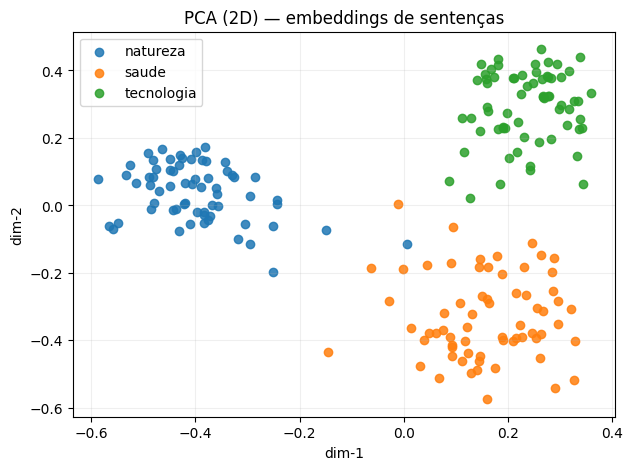

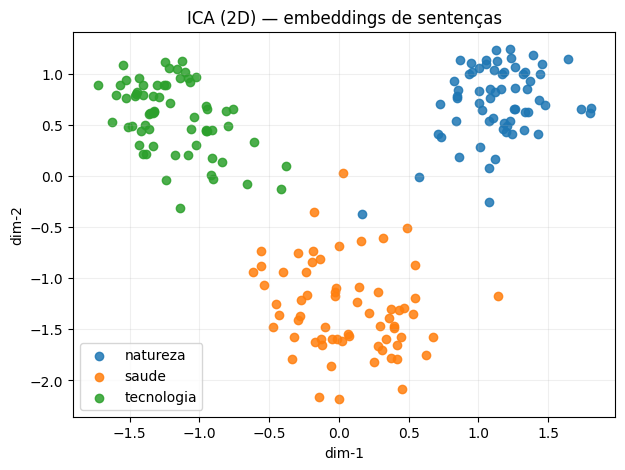

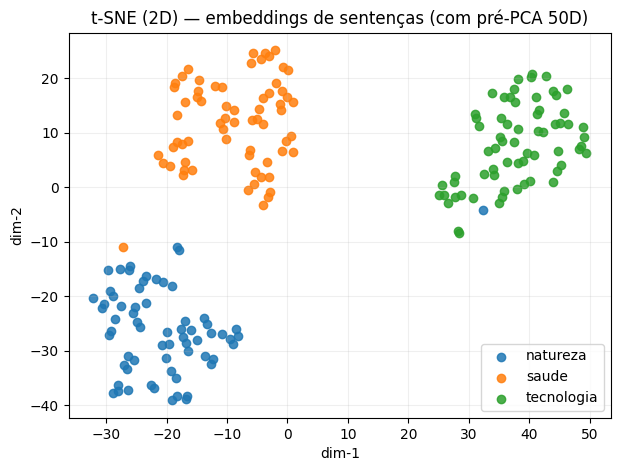

In [46]:
def plot_2d(X2, title: str, df_meta: pd.DataFrame):
    plt.figure(figsize=(7, 5))
    for label, sub in df_meta.groupby("label"):
        idx = sub.index.to_numpy()
        plt.scatter(X2[idx, 0], X2[idx, 1], label=label, alpha=0.85)
    plt.title(title)
    plt.xlabel("dim-1")
    plt.ylabel("dim-2")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

plot_2d(X_pca2, "PCA (2D) — embeddings de sentenças", df_sents)
plot_2d(X_ica2, "ICA (2D) — embeddings de sentenças", df_sents)
plot_2d(X_tsne2, "t-SNE (2D) — embeddings de sentenças (com pré-PCA 50D)", df_sents)


## 7) Embedding por documento (agregação)

Às vezes você quer um embedding **por documento**, não por sentença.  
Uma forma simples é fazer **média** dos embeddings das sentenças do documento (pode funcionar razoavelmente).

Depois, repita PCA/t-SNE para visualizar documentos.


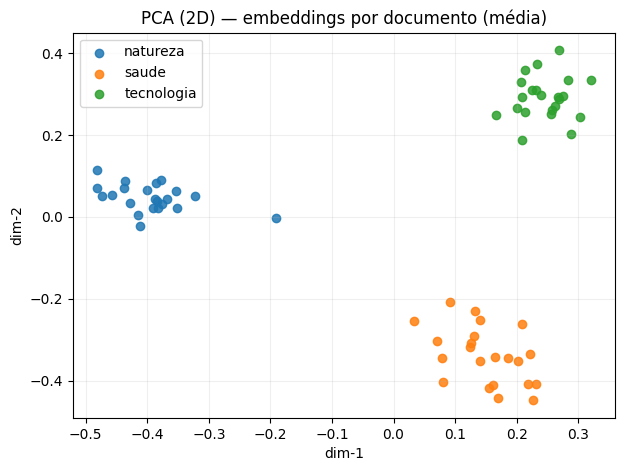

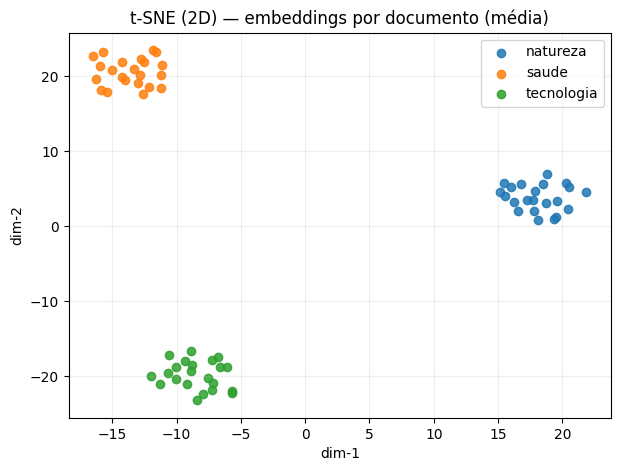

,doc_id,label
0,n1,natureza
1,n10,natureza
2,n11,natureza
3,n12,natureza
4,n13,natureza
...,...,...
61,t5,tecnologia
62,t6,tecnologia
63,t7,tecnologia
64,t8,tecnologia


In [ ]:
# Agrega por doc: média dos vetores das sentenças
df_doc_emb = (
    df_sents
    .groupby(["doc_id", "label"])["embedding"]
    .apply(lambda vs: np.mean(np.vstack(vs), axis=0))
    .reset_index()
)

X_doc = np.vstack(df_doc_emb["embedding"].to_numpy())


# t-SNE 2D (sem pré-PCA pois é pequeno)
X_doc_tsne2 = TSNE(
    n_components=2,
    perplexity=10,
    learning_rate="auto",
    init="pca",
    random_state=42,
).fit_transform(X_doc)

# PCA 2D
X_doc_pca2 = PCA(n_components=2, random_state=42).fit_transform(X_doc)

plot_2d(X_doc_tsne2, "t-SNE (2D) — embeddings por documento (média)", df_doc_emb)
plot_2d(X_doc_pca2, "PCA (2D) — embeddings por documento (média)", df_doc_emb)

df_doc_emb[["doc_id", "label"]]


# Exercícios

## Exercício A — Substitua o dataset
1. Use outro dataset com **50 a 150 documentos**, com **3 a 5 tópicos** (ex.: política, saúde, cultura, tecnologia, esporte).
2. Quebre em sentenças.
3. Gere embeddings e visualize com PCA e t-SNE.
4. Escreva 3 observações:
   - Algum tópico formou cluster claro?
   - Há sentenças “fora do lugar”? Por quê?
   - O que muda ao trocar o modelo (inglês vs multilíngue)?

## Exercício B — Variações de t-SNE
1. Teste `perplexity` em {5, 10, 30}.
2. Teste `init` em {"pca", "random"}.
3. Compare estabilidade visual (semente fixa vs outra).

## Exercício C — PCA antes do t-SNE
1. Rode t-SNE com e sem PCA prévio (50D).
2. Compare tempo e qualidade da separação.

---


Exercício A
1 -> Sim, os três tópicos foram capazes de gerar clusters claros, somente com um ou outro elemento que se distanciava da massa principal

2 -> Sim, existe algumas sentenças com o tópico de "Natureza" que estão se aproximando mais dos outros tópicos no caso de embedding de sentenças, isso provavelmente ocorre porque as sentenças estão sendo analisadas individualmente, então alguns termos em comum que esses tópicos tenham pode estar causando um peso maior na sentença sentença para o cluster errado

3 -> Ao utilizar o modelo que é especiallizado para gerar os embeddings de palavras em Inglês, os clusters no geral se aproximaram de forma razoável ao centro no caso de embedding por sentença, e no outro caso, teve 1 documento do tema "Saúde" que foi colocardo errôneamente no cluster de "Natureza"

Exercício B

1 -> Com o aumento da perplexity, no geral os documentos quando analisados individualmente ficaram mais esparsos um do outro, e uma quantidade maior deles tangenciou para mais próximo do cluster de outro tema, no plot com base na média, a perplexity 10 gerou os clusters mais próximos que em qualquer outra maneira

2 -> Não vi muita diferença com o perplexity 10

3 -> A estabilidade da entrega de resultados pareceu maior no geral utilizando perplexity 10 e o t-SNE, principalmente no plot de gráficos utilizando a média das sentenças

Exercício C

1 ->